# ======================================================
# UK Hospitality Data Analysis – Royal Thames Hotel Group
# Author: Faisal Shahzad
# Goal: Analyze hotel performance metrics such as occupancy,
# ADR (Average Daily Rate), revenue trends, and customer
# satisfaction across UK cities and hotel properties.
# LinkedIn: https://www.linkedin.com/in/faisal-analyst/
# ======================================================

## 1 Import Libraries

In [3]:
# ==================================================
# 1. Import libraries
# ==================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Optional display settings for better readability
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)

# Chart style
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

## 2 Load Datasets

In [4]:
# ==========================================
# Load Hospitality Datasets
# ==========================================

df_bookings = pd.read_csv("fact_bookings.csv")
df_date = pd.read_csv("dim_date.csv")
df_hotels = pd.read_csv("dim_hotels.csv")
df_rooms = pd.read_csv("dim_rooms.csv")
df_agg_bookings = pd.read_csv("fact_aggregated_bookings.csv")

In [ ]:
city_map = {
    "Delhi": "London",
    "Mumbai": "Manchester",
    "Hyderabad": "Birmingham",
    "Bangalore": "Edinburgh"
}

property_map = {
    "Atliq Grands": "Royal Thames Hotel",
    "Atliq Exotica": "Westminster Grand",
    "Atliq City": "Crown Plaza London",
    "Atliq Blu": "The Kensington Blu",
    "Atliq Bay": "Riverfront Bay Hotel",
    "Atliq Palace": "Buckingham Palace Suites",
    "Atliq Seasons": "Mayfair Seasons"
}
df_hotels["city"] = df_hotels["city"].replace(city_map)
df_hotels["property_name"] = df_hotels["property_name"].replace(property_map)
df_hotels.to_csv("dim_hotels_updated.csv", index=False)


## 3 Data Preview

In [223]:
# Preview datasets
df_bookings.head(5)

,booking_id,property_id,booking_date,check_in_date,checkout_date,no_guests,room_category,booking_platform,ratings_given,booking_status,revenue_generated,revenue_realized
0,May012216558RT11,16558,27-04-22,1/5/2022,2/5/2022,-3.0,RT1,direct online,1.0,Checked Out,10010,10010
1,May012216558RT12,16558,30-04-22,1/5/2022,2/5/2022,2.0,RT1,others,NaN,Cancelled,9100,3640
2,May012216558RT13,16558,28-04-22,1/5/2022,4/5/2022,2.0,RT1,logtrip,5.0,Checked Out,9100000,9100
3,May012216558RT14,16558,28-04-22,1/5/2022,2/5/2022,-2.0,RT1,others,NaN,Cancelled,9100,3640
4,May012216558RT15,16558,27-04-22,1/5/2022,2/5/2022,4.0,RT1,direct online,5.0,Checked Out,10920,10920


In [226]:
df_hotels.head(5)

,property_id,property_name,category,city
0,16558,Royal Thames Hotel,Luxury,London
1,16559,Westminster Grand,Luxury,Manchester
2,16560,Crown Plaza London,Business,London
3,16561,The Kensington Blu,Luxury,London
4,16562,Riverfront Bay Hotel,Luxury,London


In [227]:
df_rooms.head(5)

,room_id,room_class
0,RT1,Standard
1,RT2,Elite
2,RT3,Premium
3,RT4,Presidential


In [228]:
df_date.head(5)

,date,mmm yy,week no,day_type
0,01-May-22,May 22,W 19,weekend
1,02-May-22,May 22,W 19,weekeday
2,03-May-22,May 22,W 19,weekeday
3,04-May-22,May 22,W 19,weekeday
4,05-May-22,May 22,W 19,weekeday


In [229]:
df_agg_bookings.head(5)

,property_id,check_in_date,room_category,successful_bookings,capacity
0,16559,1-May-22,RT1,25,30.0
1,19562,1-May-22,RT1,28,30.0
2,19563,1-May-22,RT1,23,30.0
3,17558,1-May-22,RT1,30,19.0
4,16558,1-May-22,RT1,18,19.0


## 4 Dataset Overview

In [230]:
# Check dataset shapes

print("Bookings Shape:", df_bookings.shape)
print("Hotels Shape:", df_hotels.shape)
print("Rooms Shape:", df_rooms.shape)
print("Date Shape:", df_date.shape)
print("Aggregated Bookings Shape:", df_agg_bookings.shape)

Bookings Shape: (134590, 12)
Hotels Shape: (25, 4)
Rooms Shape: (4, 2)
Date Shape: (92, 4)
Aggregated Bookings Shape: (9200, 5)


## 5 Explore Room Categories

In [231]:
# Unique room categories in booking data

room_categories = df_bookings["room_category"].unique()

print("Room Categories:")
print(room_categories)

Room Categories:
['RT1' 'RT2' 'RT3' 'RT4']


## 6 Explore Booking Platforms

In [232]:
# Unique booking platforms

platforms = df_bookings["booking_platform"].unique()

print("Booking Platforms:")
print(platforms)

Booking Platforms:
['direct online' 'others' 'logtrip' 'tripster' 'makeyourtrip' 'journey'
 'direct offline']


## 7 Booking Platform Distribution

In [233]:
# Count bookings by platform

platform_counts = df_bookings["booking_platform"].value_counts()

print(platform_counts)

booking_platform
others            55066
makeyourtrip      26898
logtrip           14756
direct online     13379
tripster           9630
journey            8106
direct offline     6755
Name: count, dtype: int64


## 8 Booking Platform Visualization

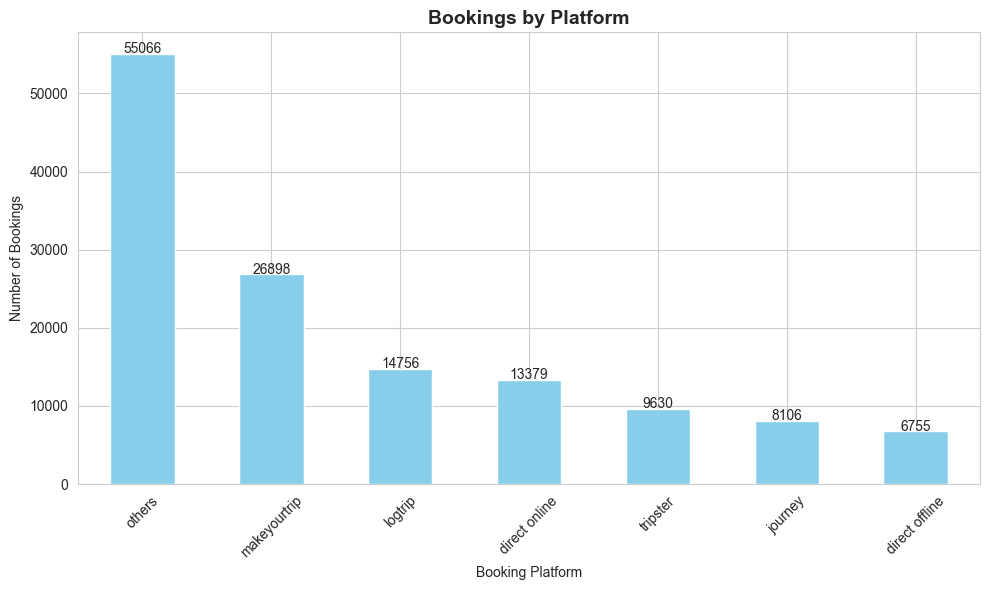

In [234]:
# Bar chart for booking platform distribution

plt.figure(figsize=(10,6))

ax = platform_counts.plot(kind="bar", color="skyblue")

plt.title("Bookings by Platform", fontsize=14, fontweight="bold")
plt.xlabel("Booking Platform")
plt.ylabel("Number of Bookings")
plt.xticks(rotation=45)

# Add labels on bars
for i, v in enumerate(platform_counts.values):
    plt.text(i, v + 50, str(v), ha="center")

plt.tight_layout()
plt.show()

## 9 Descriptive Statistics

In [235]:
# Summary statistics for numerical columns

df_bookings.describe()

,property_id,no_guests,ratings_given,revenue_generated,revenue_realized
count,134590.000000,134587.000000,56683.000000,1.345900e+05,134590.000000
mean,18061.113493,2.036170,3.619004,1.537805e+04,12696.123256
std,1093.055847,1.034885,1.235009,9.303604e+04,6928.108124
min,16558.000000,-17.000000,1.000000,6.500000e+03,2600.000000
25%,17558.000000,1.000000,3.000000,9.900000e+03,7600.000000
50%,17564.000000,2.000000,4.000000,1.350000e+04,11700.000000
75%,18563.000000,2.000000,5.000000,1.800000e+04,15300.000000
max,19563.000000,6.000000,5.000000,2.856000e+07,45220.000000


## 10 Revenue Analysis

In [236]:
# Check revenue range

min_revenue = df_bookings["revenue_generated"].min()
max_revenue = df_bookings["revenue_generated"].max()

print("Minimum Revenue:", min_revenue)
print("Maximum Revenue:", max_revenue)

Minimum Revenue: 6500
Maximum Revenue: 28560000


In [122]:
df_bookings.describe()

,property_id,no_guests,ratings_given,revenue_generated,revenue_realized
count,134590.000000,134587.000000,56683.000000,1.345900e+05,134590.000000
mean,18061.113493,2.036170,3.619004,1.537805e+04,12696.123256
std,1093.055847,1.034885,1.235009,9.303604e+04,6928.108124
min,16558.000000,-17.000000,1.000000,6.500000e+03,2600.000000
25%,17558.000000,1.000000,3.000000,9.900000e+03,7600.000000
50%,17564.000000,2.000000,4.000000,1.350000e+04,11700.000000
75%,18563.000000,2.000000,5.000000,1.800000e+04,15300.000000
max,19563.000000,6.000000,5.000000,2.856000e+07,45220.000000


In [237]:
# Count the number of hotels available in each city
city_hotel_counts = df_hotels["city"].value_counts()

# Display the results
print("Hotel Distribution by City:")
print(city_hotel_counts)

Hotel Distribution by City:
city
Manchester    8
Birmingham    6
Edinburgh     6
London        5
Name: count, dtype: int64


## 11 Visualization: Hotel distribution by city


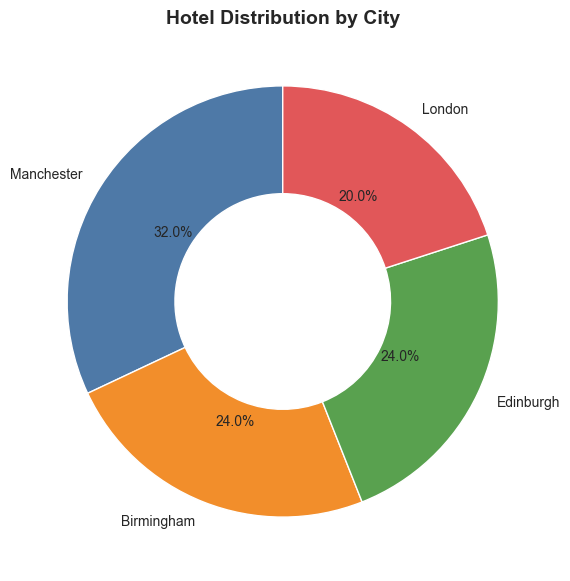

In [348]:
# =====================================================
# Visualization: Hotel Distribution by City (Donut Chart)
# =====================================================

import matplotlib.pyplot as plt

colors = ["#4E79A7", "#F28E2B", "#59A14F", "#E15759"]

plt.figure(figsize=(7,7))

plt.pie(
    city_hotel_counts,
    labels=city_hotel_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"width":0.5},
    colors=colors
)

plt.title("Hotel Distribution by City", fontsize=14, fontweight="bold")

plt.show()

## 12 Calculate total successful bookings per hotel property


In [245]:
property_successful_bookings = df_agg_bookings.groupby('property_id')['successful_bookings'].sum()

# Display the results
print("Total Successful Bookings by Property:")
print(property_successful_bookings)

Total Successful Bookings by Property:
property_id
16558    3153
16559    7338
16560    4693
16561    4418
16562    4820
16563    7211
17558    5053
17559    6142
17560    6013
17561    5183
17562    3424
17563    6337
17564    3982
18558    4475
18559    5256
18560    6638
18561    6458
18562    7333
18563    4737
19558    4400
19559    4729
19560    6079
19561    5736
19562    5812
19563    5413
Name: successful_bookings, dtype: int64


## 13 Identify properties where successful bookings exceed capacity

In [246]:
# Filter properties where bookings are greater than the available capacity
overbooked_properties = df_agg_bookings[
    df_agg_bookings.successful_bookings > df_agg_bookings.capacity
]

# Display overbooked records
print("Overbooked Properties:")
display(overbooked_properties)

Overbooked Properties:


,property_id,check_in_date,room_category,successful_bookings,capacity
3,17558,1-May-22,RT1,30,19.0
12,16563,1-May-22,RT1,100,41.0
4136,19558,11-Jun-22,RT2,50,39.0
6209,19560,2-Jul-22,RT1,123,26.0
8522,19559,25-Jul-22,RT1,35,24.0
9194,18563,31-Jul-22,RT4,20,18.0


If successful bookings exceed capacity, it indicates overbooking situations, which can lead to operational challenges and customer dissatisfaction.

In [249]:
# =====================================================
#  Determine the maximum capacity among all hotel properties
# =====================================================

# Find the maximum capacity value in the dataset
max_capacity = df_agg_bookings.capacity.max()

print("Maximum Hotel Capacity:", max_capacity)

Maximum Hotel Capacity: 50.0


In [251]:
df_agg_bookings[df_agg_bookings.capacity==df_agg_bookings.capacity.max()]

,property_id,check_in_date,room_category,successful_bookings,capacity
27,17558,1-May-22,RT2,38,50.0
128,17558,2-May-22,RT2,27,50.0
229,17558,3-May-22,RT2,26,50.0
328,17558,4-May-22,RT2,27,50.0
428,17558,5-May-22,RT2,29,50.0
...,...,...,...,...,...
8728,17558,27-Jul-22,RT2,22,50.0
8828,17558,28-Jul-22,RT2,21,50.0
8928,17558,29-Jul-22,RT2,23,50.0
9028,17558,30-Jul-22,RT2,32,50.0


# Data Cleaning

In [140]:
df_bookings.describe()

,property_id,no_guests,ratings_given,revenue_generated,revenue_realized
count,134590.000000,134587.000000,56683.000000,1.345900e+05,134590.000000
mean,18061.113493,2.036170,3.619004,1.537805e+04,12696.123256
std,1093.055847,1.034885,1.235009,9.303604e+04,6928.108124
min,16558.000000,-17.000000,1.000000,6.500000e+03,2600.000000
25%,17558.000000,1.000000,3.000000,9.900000e+03,7600.000000
50%,17564.000000,2.000000,4.000000,1.350000e+04,11700.000000
75%,18563.000000,2.000000,5.000000,1.800000e+04,15300.000000
max,19563.000000,6.000000,5.000000,2.856000e+07,45220.000000


In [141]:
df_bookings.shape

(134590, 12)

# Remove Invalid Guest Records

In [252]:
# =====================================================
# Step 1: Identify records with invalid number of guests
# =====================================================

# Find rows where number of guests is less than or equal to zero
invalid_guest_records = df_bookings[df_bookings.no_guests <= 0]

# Display invalid records
display(invalid_guest_records)

,booking_id,property_id,booking_date,check_in_date,checkout_date,no_guests,room_category,booking_platform,ratings_given,booking_status,revenue_generated,revenue_realized
0,May012216558RT11,16558,27-04-22,1/5/2022,2/5/2022,-3.0,RT1,direct online,1.0,Checked Out,10010,10010
3,May012216558RT14,16558,28-04-22,1/5/2022,2/5/2022,-2.0,RT1,others,NaN,Cancelled,9100,3640
17924,May122218559RT44,18559,12/5/2022,12/5/2022,14-05-22,-10.0,RT4,direct online,NaN,No Show,20900,20900
18020,May122218561RT22,18561,8/5/2022,12/5/2022,14-05-22,-12.0,RT2,makeyourtrip,NaN,Cancelled,9000,3600
18119,May122218562RT311,18562,5/5/2022,12/5/2022,17-05-22,-6.0,RT3,direct offline,5.0,Checked Out,16800,16800
18121,May122218562RT313,18562,10/5/2022,12/5/2022,17-05-22,-4.0,RT3,direct online,NaN,Cancelled,14400,5760
56715,Jun082218562RT12,18562,5/6/2022,8/6/2022,13-06-22,-17.0,RT1,others,NaN,Checked Out,6500,6500
119765,Jul202219560RT220,19560,19-07-22,20-07-22,22-07-22,-1.0,RT2,others,NaN,Checked Out,13500,13500
134586,Jul312217564RT47,17564,30-07-22,31-07-22,1/8/2022,-4.0,RT4,logtrip,2.0,Checked Out,38760,38760


In [253]:
# =====================================================
# Step 2: Remove records where guest count is zero or negative
# =====================================================

df_bookings = df_bookings[df_bookings.no_guests > 0]

# Check dataset size after cleaning
print("Dataset shape after removing invalid guest records:", df_bookings.shape)

Dataset shape after removing invalid guest records: (134578, 12)


# Check Revenue Range

In [254]:
# =====================================================
# Step 3: Check minimum and maximum revenue values
# =====================================================

min_revenue = df_bookings.revenue_generated.min()
max_revenue = df_bookings.revenue_generated.max()

print("Minimum Revenue:", min_revenue)
print("Maximum Revenue:", max_revenue)

Minimum Revenue: 6500
Maximum Revenue: 28560000


#  Detect Revenue Outliers (3-Sigma Rule)

In [255]:
# =====================================================
# Step 4: Calculate mean and standard deviation of revenue
# =====================================================

avg_revenue = df_bookings.revenue_generated.mean()
std_revenue = df_bookings.revenue_generated.std()

print("Average Revenue:", avg_revenue)
print("Revenue Standard Deviation:", std_revenue)

Average Revenue: 15378.036937686695
Revenue Standard Deviation: 93040.1549314641


# Calculate Outlier Limits

In [256]:
# =====================================================
# Step 5: Calculate upper and lower outlier limits
# Using the 3-Sigma rule
# =====================================================

higher_limit = avg_revenue + 3 * std_revenue
lower_limit = avg_revenue - 3 * std_revenue

print("Upper Outlier Limit:", higher_limit)
print("Lower Outlier Limit:", lower_limit)

Upper Outlier Limit: 294498.50173207896
Lower Outlier Limit: -263742.4278567056


Explanation

The 3-Sigma rule states that most values in a normal distribution lie within 3 standard deviations from the mean. Values outside this range are considered outliers.

# Identify Revenue Outliers

In [257]:
# =====================================================
# Step 6: Identify bookings where revenue exceeds the upper limit
# =====================================================

revenue_outliers = df_bookings[df_bookings.revenue_generated > higher_limit]

display(revenue_outliers)

,booking_id,property_id,booking_date,check_in_date,checkout_date,no_guests,room_category,booking_platform,ratings_given,booking_status,revenue_generated,revenue_realized
2,May012216558RT13,16558,28-04-22,1/5/2022,4/5/2022,2.0,RT1,logtrip,5.0,Checked Out,9100000,9100
111,May012216559RT32,16559,29-04-22,1/5/2022,2/5/2022,6.0,RT3,direct online,NaN,Checked Out,28560000,28560
315,May012216562RT22,16562,28-04-22,1/5/2022,4/5/2022,2.0,RT2,direct offline,3.0,Checked Out,12600000,12600
562,May012217559RT118,17559,26-04-22,1/5/2022,2/5/2022,2.0,RT1,others,NaN,Cancelled,2000000,4420
129176,Jul282216562RT26,16562,21-07-22,28-07-22,29-07-22,2.0,RT2,direct online,3.0,Checked Out,10000000,12600


# Remove Revenue Outliers

In [258]:
# =====================================================
# Step 7: Remove revenue outliers from the dataset
# =====================================================

df_bookings = df_bookings[df_bookings.revenue_generated < higher_limit]

# Verify dataset size after removing outliers
print("Dataset shape after removing revenue outliers:", df_bookings.shape)

Dataset shape after removing revenue outliers: (134573, 12)


# Revenue Realized Outlier Analysis
### Objective

In this section, we analyze revenue_realized to detect potential outliers using the 3-Sigma rule.
We also investigate whether high values belong to premium room categories, which may be valid business cases.

# Summary Statistics for Revenue Realized

In [259]:
# =====================================================
# Step 1: Explore descriptive statistics for revenue_realized
# =====================================================

# Generate summary statistics
df_bookings.revenue_realized.describe()

count    134573.000000
mean      12695.983585
std        6927.791692
min        2600.000000
25%        7600.000000
50%       11700.000000
75%       15300.000000
max       45220.000000
Name: revenue_realized, dtype: float64

### Observation

The maximum revenue value appears to be 45220.
We need to verify whether this value is an outlier or a valid premium booking.

# Calculate Mean and Standard Deviation

In [260]:
# =====================================================
# Step 2: Calculate mean and standard deviation
# =====================================================

avg1 = df_bookings.revenue_realized.mean()
std1 = df_bookings.revenue_realized.std()

print("Average Revenue Realized:", avg1)
print("Standard Deviation:", std1)

Average Revenue Realized: 12695.983585117372
Standard Deviation: 6927.791692242814


# Calculate Upper Outlier Limit (3-Sigma Rule)

In [261]:
# =====================================================
# Step 3: Calculate upper limit for detecting outliers
# =====================================================

higher_limit1 = avg1 + 3 * std1

print("Upper Outlier Limit:", higher_limit1)

Upper Outlier Limit: 33479.358661845814


## Explanation

According to the 3-Sigma rule, values greater than this limit are considered statistical outliers

# Identify Revenue Realized Outliers

In [262]:
# =====================================================
# Step 4: Identify records exceeding the upper limit
# =====================================================

revenue_realized_outliers = df_bookings[
    df_bookings.revenue_realized > higher_limit1
]

display(revenue_realized_outliers)

,booking_id,property_id,booking_date,check_in_date,checkout_date,no_guests,room_category,booking_platform,ratings_given,booking_status,revenue_generated,revenue_realized
137,May012216559RT41,16559,27-04-22,1/5/2022,7/5/2022,4.0,RT4,others,NaN,Checked Out,38760,38760
139,May012216559RT43,16559,1/5/2022,1/5/2022,2/5/2022,6.0,RT4,tripster,3.0,Checked Out,45220,45220
143,May012216559RT47,16559,28-04-22,1/5/2022,3/5/2022,3.0,RT4,others,5.0,Checked Out,35530,35530
149,May012216559RT413,16559,24-04-22,1/5/2022,7/5/2022,5.0,RT4,logtrip,NaN,Checked Out,41990,41990
222,May012216560RT45,16560,30-04-22,1/5/2022,3/5/2022,5.0,RT4,others,3.0,Checked Out,34580,34580
...,...,...,...,...,...,...,...,...,...,...,...,...
134328,Jul312219560RT49,19560,31-07-22,31-07-22,2/8/2022,6.0,RT4,direct online,5.0,Checked Out,39900,39900
134331,Jul312219560RT412,19560,31-07-22,31-07-22,1/8/2022,6.0,RT4,others,2.0,Checked Out,39900,39900
134467,Jul312219562RT45,19562,28-07-22,31-07-22,1/8/2022,6.0,RT4,makeyourtrip,4.0,Checked Out,39900,39900
134474,Jul312219562RT412,19562,25-07-22,31-07-22,6/8/2022,5.0,RT4,direct offline,5.0,Checked Out,37050,37050


### Observation

There are 1299 rows exceeding the calculated limit.

However, before removing them, we must verify whether they belong to premium room categories.

In [263]:
# =====================================================
# Step 5: Check room category for high revenue bookings
# =====================================================

df_bookings[df_bookings.room_category == "RT4"].revenue_realized.describe()

count    16071.000000
mean     23439.308444
std       9048.599076
min       7600.000000
25%      19000.000000
50%      26600.000000
75%      32300.000000
max      45220.000000
Name: revenue_realized, dtype: float64

### Observation

The outliers belong to RT4 room category, which corresponds to Presidential rooms.

Presidential suites typically have significantly higher pricing.

# Calculate Outlier Threshold for RT4 Category

In [264]:
# =====================================================
# Step 6: Calculate outlier limit specifically for RT4 rooms
# =====================================================

new_higher_limit = 23439.308444 + 3 * 9048.599076

print("New Outlier Limit for RT4:", new_higher_limit)

New Outlier Limit for RT4: 50585.105672000005


# Result
    New Outlier Limit ≈ 50585
    Since the maximum revenue observed is 45220, which is below the new threshold, these values are valid premium bookings.

# Handling Missing Values (NaN)

## Objective

In this section, we identify and handle missing values in the datasets to ensure the data is complete and suitable for analysis.

### 1 Check Missing Values in Bookings Dataset

In [265]:
# =====================================================
# Step 1: Check for missing values in the bookings dataset
# =====================================================

df_bookings.isnull().sum()

booking_id               0
property_id              0
booking_date             0
check_in_date            0
checkout_date            0
no_guests                0
room_category            0
booking_platform         0
ratings_given        77897
booking_status           0
revenue_generated        0
revenue_realized         0
dtype: int64

## Observation

The rating_given column contains 77,897 missing values.

This is acceptable because:

Not every customer leaves a rating

Missing ratings do not affect booking or revenue analysis

Therefore, we keep these values as NaN.

### 2 Check Missing Values in Aggregated Bookings Dataset

In [268]:
# =====================================================
# Step 2: Identify missing values in aggregated bookings
# =====================================================

df_agg_bookings.isnull().sum()

property_id            0
check_in_date          0
room_category          0
successful_bookings    0
capacity               2
dtype: int64

### 3 Identify Rows with Missing Capacity

In [269]:
# =====================================================
# Step 3: Find rows where capacity values are missing
# =====================================================

df_agg_bookings[df_agg_bookings.capacity.isna()]

,property_id,check_in_date,room_category,successful_bookings,capacity
8,17561,1-May-22,RT1,22,NaN
14,17562,1-May-22,RT1,12,NaN


### 4 Calculate Median Capacity

In [271]:
# =====================================================
# Step 4: Calculate the median capacity
# =====================================================

median_capacity = df_agg_bookings.capacity.median()

print("Median Capacity:", median_capacity)

Median Capacity: 25.0


### Why Median?

We use median instead of mean because:

It is less affected by outliers

It represents a typical room capacity value

### 5 Fill Missing Capacity Values

In [350]:
# =====================================================
# Step 5: Replace missing capacity values with the median
# =====================================================

df_agg_bookings["capacity"] = df_agg_bookings["capacity"].fillna(median_capacity)

### 6 Verify Filled Values

In [273]:
# =====================================================
# Step 6: Verify that missing values were filled
# =====================================================

df_agg_bookings.loc[[8, 14]]

,property_id,check_in_date,room_category,successful_bookings,capacity
8,17561,1-May-22,RT1,22,25.0
14,17562,1-May-22,RT1,12,25.0


This confirms that the previously missing capacity values are now replaced with the median.

In [162]:
df_agg_bookings.loc[[8,14]]

,property_id,check_in_date,room_category,successful_bookings,capacity
8,17561,1-May-22,RT1,22,25.0
14,17562,1-May-22,RT1,12,25.0


# Data Validation
### Objective

Ensure that successful bookings do not exceed the available capacity.

# 7 Check Dataset Size Before Filtering

In [275]:
# =====================================================
# Step 7: Check dataset shape before removing invalid records
# =====================================================

print("Dataset shape before filtering:", df_agg_bookings.shape)

Dataset shape before filtering: (9200, 5)


# 8 Remove Invalid Booking Records

In [276]:
# =====================================================
# Step 8: Remove records where successful bookings exceed capacity
# =====================================================

df_agg_bookings = df_agg_bookings[
    df_agg_bookings.successful_bookings <= df_agg_bookings.capacity
]

# 9 Verify Dataset Size After Cleaning

In [277]:
# =====================================================
# Step 9: Check dataset shape after removing invalid records
# =====================================================

print("Dataset shape after filtering:", df_agg_bookings.shape)

Dataset shape after filtering: (9194, 5)


# Data Transformation

### Occupancy Percentage Calculation
#### Objective

In this step, we calculate the Occupancy Percentage (occ_pct) for each property.

Occupancy percentage indicates how many rooms were successfully booked compared to the total available capacity.

### Calculate Occupancy Ratio

In [166]:
df_agg_bookings.head(5)

,property_id,check_in_date,room_category,successful_bookings,capacity
0,16559,1-May-22,RT1,25,30.0
1,19562,1-May-22,RT1,28,30.0
2,19563,1-May-22,RT1,23,30.0
4,16558,1-May-22,RT1,18,19.0
5,17560,1-May-22,RT1,28,40.0


In [278]:
# =====================================================
# Step 1: Calculate occupancy ratio
# =====================================================

# Occupancy ratio = successful bookings divided by capacity
df_agg_bookings["occ_pct"] = (
    df_agg_bookings["successful_bookings"] /
    df_agg_bookings["capacity"]
)

# Preview dataset
df_agg_bookings.head()

,property_id,check_in_date,room_category,successful_bookings,capacity,occ_pct
0,16559,1-May-22,RT1,25,30.0,0.833333
1,19562,1-May-22,RT1,28,30.0,0.933333
2,19563,1-May-22,RT1,23,30.0,0.766667
4,16558,1-May-22,RT1,18,19.0,0.947368
5,17560,1-May-22,RT1,28,40.0,0.700000


### Convert Ratio to Percentage

In [169]:
df_agg_bookings

,property_id,check_in_date,room_category,successful_bookings,capacity,occ_pct
0,16559,1-May-22,RT1,25,30.0,0.833333
1,19562,1-May-22,RT1,28,30.0,0.933333
2,19563,1-May-22,RT1,23,30.0,0.766667
4,16558,1-May-22,RT1,18,19.0,0.947368
5,17560,1-May-22,RT1,28,40.0,0.700000
...,...,...,...,...,...,...
9195,16563,31-Jul-22,RT4,13,18.0,0.722222
9196,16559,31-Jul-22,RT4,13,18.0,0.722222
9197,17558,31-Jul-22,RT4,3,6.0,0.500000
9198,19563,31-Jul-22,RT4,3,6.0,0.500000


In [279]:
# =====================================================
# Step 2: Convert occupancy ratio into percentage
# =====================================================

df_agg_bookings["occ_pct"] = df_agg_bookings["occ_pct"].apply(
    lambda x: round(x * 100, 2)
)

# Display updated dataset
df_agg_bookings.head()

,property_id,check_in_date,room_category,successful_bookings,capacity,occ_pct
0,16559,1-May-22,RT1,25,30.0,83.33
1,19562,1-May-22,RT1,28,30.0,93.33
2,19563,1-May-22,RT1,23,30.0,76.67
4,16558,1-May-22,RT1,18,19.0,94.74
5,17560,1-May-22,RT1,28,40.0,70.00


There are various types of data transformations that you may have to perform based on the need. Few examples of data transformations are,

1. Creating new columns
1. Normalization
1. Merging data
1. Aggregation

# Insights Generation

## **1. What is an average occupancy rate in each of the room categories?**

In [172]:
df_agg_bookings.head(5)

,property_id,check_in_date,room_category,successful_bookings,capacity,occ_pct
0,16559,1-May-22,RT1,25,30.0,83.33
1,19562,1-May-22,RT1,28,30.0,93.33
2,19563,1-May-22,RT1,23,30.0,76.67
4,16558,1-May-22,RT1,18,19.0,94.74
5,17560,1-May-22,RT1,28,40.0,70.00


In [280]:
# =====================================================
# Step 1: Calculate average occupancy percentage for each room category
# =====================================================

df_agg_bookings.groupby('room_category')['occ_pct'].mean().round(2)

room_category
RT1    57.89
RT2    58.01
RT3    58.03
RT4    59.28
Name: occ_pct, dtype: float64

### Explanation

We group the dataset by room_category

Then calculate the average occupancy percentage

In [174]:
df_rooms 

,room_id,room_class
0,RT1,Standard
1,RT2,Elite
2,RT3,Premium
3,RT4,Presidential


### Merge Room Dataset to Get Room Class Names

In [282]:
# =====================================================
# Step 2: Merge aggregated bookings dataset with room dataset
# =====================================================

df = pd.merge(
    df_agg_bookings,
    df_rooms,
    left_on='room_category',
    right_on='room_id'
)

# Preview merged dataset
df.head(5)

,property_id,check_in_date,room_category,successful_bookings,capacity,occ_pct,room_id,room_class
0,16559,1-May-22,RT1,25,30.0,83.33,RT1,Standard
1,19562,1-May-22,RT1,28,30.0,93.33,RT1,Standard
2,19563,1-May-22,RT1,23,30.0,76.67,RT1,Standard
3,16558,1-May-22,RT1,18,19.0,94.74,RT1,Standard
4,17560,1-May-22,RT1,28,40.0,70.00,RT1,Standard


### Why Merge?

The room_category column contains IDs (RT1, RT2, etc.).
By merging with df_rooms, we get actual room class names like:

Standard

Elite

Premium

Presidential

### Average Occupancy by Room Class

In [283]:
# =====================================================
# Step 3: Calculate average occupancy by room class
# =====================================================

df.groupby('room_class')['occ_pct'].mean().round(2)

room_class
Elite           58.01
Premium         58.03
Presidential    59.28
Standard        57.89
Name: occ_pct, dtype: float64

### Remove Unnecessary Column

In [284]:
# =====================================================
# Step 4: Remove duplicate column created during merge
# =====================================================

df.drop('room_id', axis=1, inplace=True)

df.head(5)

,property_id,check_in_date,room_category,successful_bookings,capacity,occ_pct,room_class
0,16559,1-May-22,RT1,25,30.0,83.33,Standard
1,19562,1-May-22,RT1,28,30.0,93.33,Standard
2,19563,1-May-22,RT1,23,30.0,76.67,Standard
3,16558,1-May-22,RT1,18,19.0,94.74,Standard
4,17560,1-May-22,RT1,28,40.0,70.00,Standard


In [178]:
df[df.room_class=="Standard"].occ_pct.mean()

np.float64(57.88964285714285)

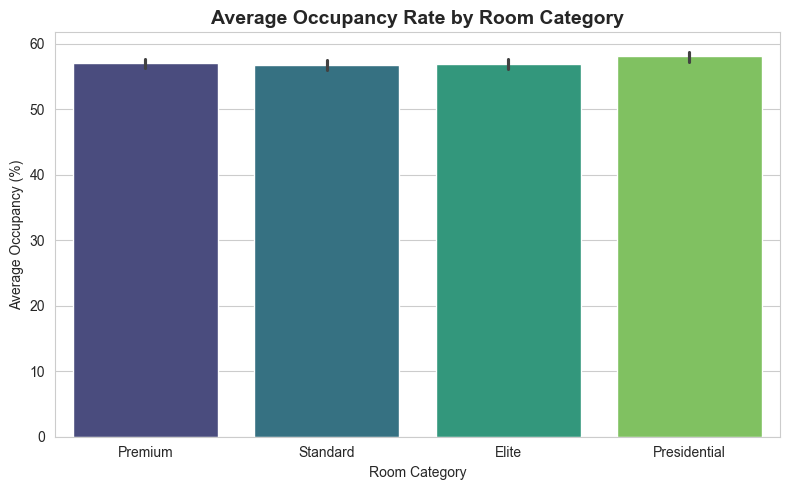

In [351]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x='room_class',
    y='occ_pct',
    hue='room_class',     # fix warning
    estimator='mean',
    palette='viridis',
    legend=False
)

plt.title("Average Occupancy Rate by Room Category", fontsize=14, fontweight='bold')
plt.xlabel("Room Category")
plt.ylabel("Average Occupancy (%)")

plt.tight_layout()
plt.show()

## **2. Print average occupancy rate per city**
This analysis helps identify which cities have higher hotel occupancy, indicating stronger tourism demand or hotel performance.

In [179]:
df_hotels.head(5)

,property_id,property_name,category,city
0,16558,Royal Thames Hotel,Luxury,London
1,16559,Westminster Grand,Luxury,Manchester
2,16560,Crown Plaza London,Business,London
3,16561,The Kensington Blu,Luxury,London
4,16562,Riverfront Bay Hotel,Luxury,London


In [180]:
df.head(5)

,property_id,check_in_date,room_category,successful_bookings,capacity,occ_pct,room_class
0,16559,1-May-22,RT1,25,30.0,83.33,Standard
1,19562,1-May-22,RT1,28,30.0,93.33,Standard
2,19563,1-May-22,RT1,23,30.0,76.67,Standard
3,16558,1-May-22,RT1,18,19.0,94.74,Standard
4,17560,1-May-22,RT1,28,40.0,70.00,Standard


In [291]:
# =====================================================
# Step 1: Merge aggregated bookings dataset with hotel dataset
# =====================================================

# Merge datasets to get city information for each property
df = pd.merge(df, df_hotels, on="property_id")

# Preview merged dataset
df.head(3)

,property_id,check_in_date,room_category,successful_bookings,capacity,occ_pct,room_class,property_name_x,category_x,city_x,property_name_y,category_y,city_y
0,16559,1-May-22,RT1,25,30.0,83.33,Standard,Westminster Grand,Luxury,Manchester,Westminster Grand,Luxury,Manchester
1,19562,1-May-22,RT1,28,30.0,93.33,Standard,Riverfront Bay Hotel,Luxury,Edinburgh,Riverfront Bay Hotel,Luxury,Edinburgh
2,19563,1-May-22,RT1,23,30.0,76.67,Standard,Buckingham Palace Suites,Business,Edinburgh,Buckingham Palace Suites,Business,Edinburgh


### Why Merge?

The df_hotels dataset contains city information, which is not available in the aggregated bookings dataset.
Merging allows us to analyze occupancy by city.

In [293]:
# =====================================================
# Step 2: Calculate average occupancy percentage for each city
# =====================================================

avg_occ_city = df.groupby('city_x')['occ_pct'].mean().round(2)

print("Average Occupancy Rate by City:")
print(avg_occ_city)

Average Occupancy Rate by City:
city_x
Birmingham    58.12
Edinburgh     56.33
London        61.51
Manchester    57.91
Name: occ_pct, dtype: float64


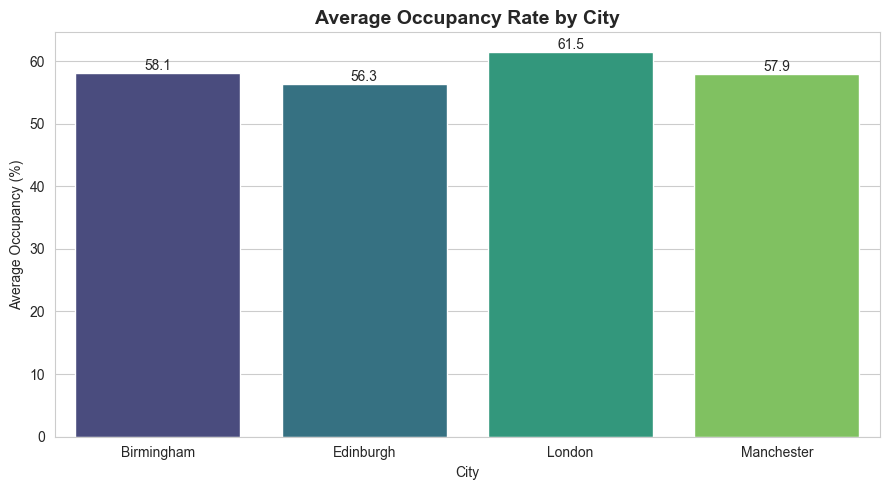

In [296]:

plt.figure(figsize=(9,5))

ax = sns.barplot(
    x=avg_occ_city.index,
    y=avg_occ_city.values,
    hue=avg_occ_city.index,
    palette="viridis",
    legend=False
)

plt.title("Average Occupancy Rate by City", fontsize=14, fontweight="bold")
plt.xlabel("City")
plt.ylabel("Average Occupancy (%)")

# Add labels on bars
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f")

plt.tight_layout()
plt.show()

##  **3. When was the occupancy better? Weekday or Weekend?**

In [184]:
df_date.head(4)

,date,mmm yy,week no,day_type
0,01-May-22,May 22,W 19,weekend
1,02-May-22,May 22,W 19,weekeday
2,03-May-22,May 22,W 19,weekeday
3,04-May-22,May 22,W 19,weekeday


In [300]:
df=pd.merge(df,df_date,left_on='check_in_date',right_on='date')
df

,property_id,check_in_date,room_category,successful_bookings,capacity,occ_pct,room_class,property_name,category,city,date,mmm yy,week no,day_type
0,19563,10-May-22,RT3,15,29.0,51.72,Premium,Buckingham Palace Suites,Business,Edinburgh,10-May-22,May 22,W 20,weekeday
1,18560,10-May-22,RT1,19,30.0,63.33,Standard,Crown Plaza London,Business,Birmingham,10-May-22,May 22,W 20,weekeday
2,19562,10-May-22,RT1,18,30.0,60.00,Standard,Riverfront Bay Hotel,Luxury,Edinburgh,10-May-22,May 22,W 20,weekeday
3,19563,10-May-22,RT1,16,30.0,53.33,Standard,Buckingham Palace Suites,Business,Edinburgh,10-May-22,May 22,W 20,weekeday
4,17558,10-May-22,RT1,11,19.0,57.89,Standard,Royal Thames Hotel,Luxury,Manchester,10-May-22,May 22,W 20,weekeday
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6492,16563,31-Jul-22,RT4,13,18.0,72.22,Presidential,Buckingham Palace Suites,Business,London,31-Jul-22,Jul 22,W 32,weekend
6493,16559,31-Jul-22,RT4,13,18.0,72.22,Presidential,Westminster Grand,Luxury,Manchester,31-Jul-22,Jul 22,W 32,weekend
6494,17558,31-Jul-22,RT4,3,6.0,50.00,Presidential,Royal Thames Hotel,Luxury,Manchester,31-Jul-22,Jul 22,W 32,weekend
6495,19563,31-Jul-22,RT4,3,6.0,50.00,Presidential,Buckingham Palace Suites,Business,Edinburgh,31-Jul-22,Jul 22,W 32,weekend


In [302]:
df.groupby('day_type')['occ_pct'].mean().round(2)



day_type
weekeday    50.88
weekend     72.34
Name: occ_pct, dtype: float64

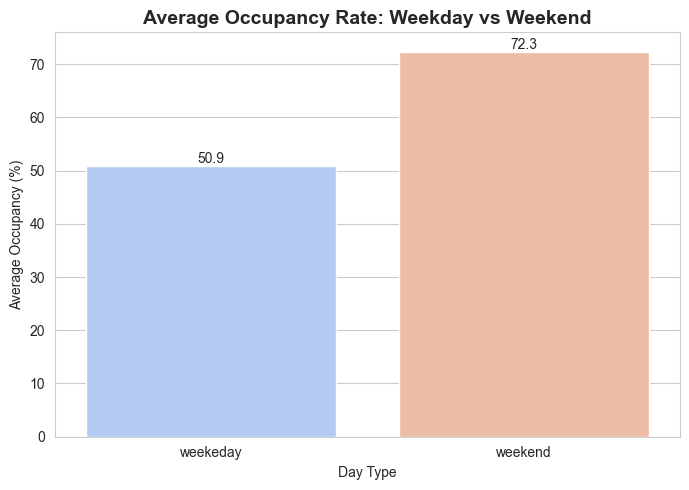

In [303]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate average occupancy by day type
occ_daytype = df.groupby('day_type')['occ_pct'].mean().round(2).reset_index()

plt.figure(figsize=(7,5))

ax = sns.barplot(
    data=occ_daytype,
    x='day_type',
    y='occ_pct',
    hue='day_type',
    palette='coolwarm',
    legend=False
)

plt.title("Average Occupancy Rate: Weekday vs Weekend", fontsize=14, fontweight='bold')
plt.xlabel("Day Type")
plt.ylabel("Average Occupancy (%)")

# Add value labels
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f")

plt.tight_layout()
plt.show()

## **4: In the month of June, what is the occupancy for different cities**

In [304]:

df['mmm yy'].unique()

array(['May 22', 'Jun 22', 'Jul 22'], dtype=object)

In [305]:
df_june_22 = df[df["mmm yy"]=="Jun 22"]
df_june_22.head(4)

,property_id,check_in_date,room_category,successful_bookings,capacity,occ_pct,room_class,property_name,category,city,date,mmm yy,week no,day_type
2200,16559,10-Jun-22,RT1,20,30.0,66.67,Standard,Westminster Grand,Luxury,Manchester,10-Jun-22,Jun 22,W 24,weekeday
2201,19562,10-Jun-22,RT1,19,30.0,63.33,Standard,Riverfront Bay Hotel,Luxury,Edinburgh,10-Jun-22,Jun 22,W 24,weekeday
2202,19563,10-Jun-22,RT1,17,30.0,56.67,Standard,Buckingham Palace Suites,Business,Edinburgh,10-Jun-22,Jun 22,W 24,weekeday
2203,17558,10-Jun-22,RT1,9,19.0,47.37,Standard,Royal Thames Hotel,Luxury,Manchester,10-Jun-22,Jun 22,W 24,weekeday


In [307]:

df_june_22.groupby('city')['occ_pct'].mean().round(2).sort_values(ascending=False)

city
London        62.47
Birmingham    58.46
Manchester    58.38
Edinburgh     56.44
Name: occ_pct, dtype: float64

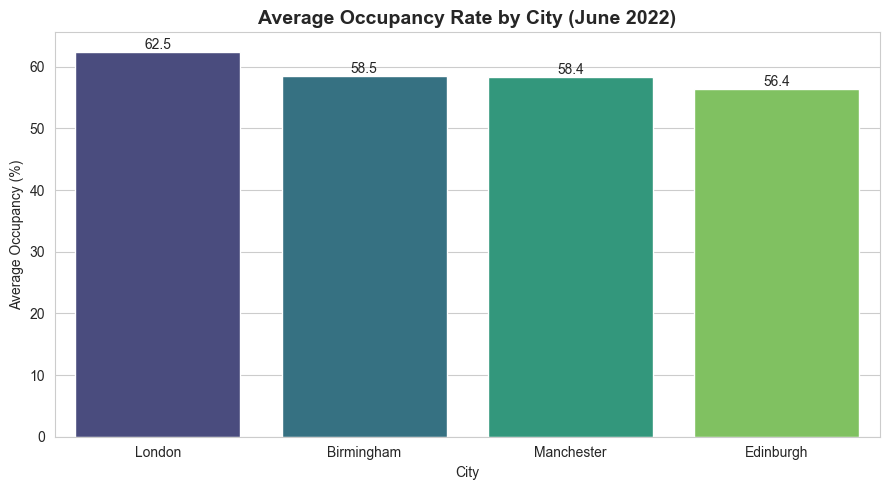

In [311]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate occupancy by city for June
city_occ_june = (
    df_june_22.groupby('city')['occ_pct']
    .mean()
    .round(2)
    .sort_values(ascending=False)
    .reset_index()
)

plt.figure(figsize=(9,5))

ax = sns.barplot(
    data=city_occ_june,
    x='city',
    y='occ_pct',
    hue='city',
    palette='viridis',
    legend=False
)

plt.title("Average Occupancy Rate by City (June 2022)", fontsize=14, fontweight="bold")
plt.xlabel("City")
plt.ylabel("Average Occupancy (%)")

# Add labels on bars
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f")

plt.tight_layout()
plt.show()

## **5: We got new data for the month of august. Append that to existing data**

In [312]:
df_august=pd.read_csv('new_data_august.csv')
df_august.head(4)

,property_id,property_name,category,city,room_category,room_class,check_in_date,mmm yy,week no,day_type,successful_bookings,capacity,occ%
0,16559,Atliq Exotica,Luxury,Mumbai,RT1,Standard,01-Aug-22,Aug-22,W 32,weekeday,30,30,100.00
1,19562,Atliq Bay,Luxury,Bangalore,RT1,Standard,01-Aug-22,Aug-22,W 32,weekeday,21,30,70.00
2,19563,Atliq Palace,Business,Bangalore,RT1,Standard,01-Aug-22,Aug-22,W 32,weekeday,23,30,76.67
3,19558,Atliq Grands,Luxury,Bangalore,RT1,Standard,01-Aug-22,Aug-22,W 32,weekeday,30,40,75.00


In [313]:
df_august.columns

Index(['property_id', 'property_name', 'category', 'city', 'room_category', 'room_class', 'check_in_date', 'mmm yy', 'week no', 'day_type', 'successful_bookings', 'capacity', 'occ%'], dtype='object')

In [ ]:
df.columns

In [314]:
latest_df=pd.concat([df,df_august],ignore_index=True,axis=0)
latest_df.head(7)

,property_id,check_in_date,room_category,successful_bookings,capacity,occ_pct,room_class,property_name,category,city,date,mmm yy,week no,day_type,occ%
0,19563,10-May-22,RT3,15,29.0,51.72,Premium,Buckingham Palace Suites,Business,Edinburgh,10-May-22,May 22,W 20,weekeday,NaN
1,18560,10-May-22,RT1,19,30.0,63.33,Standard,Crown Plaza London,Business,Birmingham,10-May-22,May 22,W 20,weekeday,NaN
2,19562,10-May-22,RT1,18,30.0,60.00,Standard,Riverfront Bay Hotel,Luxury,Edinburgh,10-May-22,May 22,W 20,weekeday,NaN
3,19563,10-May-22,RT1,16,30.0,53.33,Standard,Buckingham Palace Suites,Business,Edinburgh,10-May-22,May 22,W 20,weekeday,NaN
4,17558,10-May-22,RT1,11,19.0,57.89,Standard,Royal Thames Hotel,Luxury,Manchester,10-May-22,May 22,W 20,weekeday,NaN
5,16558,10-May-22,RT1,10,19.0,52.63,Standard,Royal Thames Hotel,Luxury,London,10-May-22,May 22,W 20,weekeday,NaN
6,17560,10-May-22,RT1,19,40.0,47.50,Standard,Crown Plaza London,Business,Manchester,10-May-22,May 22,W 20,weekeday,NaN


In [315]:
latest_df.shape

(6504, 15)

In [316]:
latest_df['mmm yy'].unique()

array(['May 22', 'Jun 22', 'Jul 22', 'Aug-22'], dtype=object)

## print revenue realized per city

In [190]:
df_bookings.head(4)

,booking_id,property_id,booking_date,check_in_date,checkout_date,no_guests,room_category,booking_platform,ratings_given,booking_status,revenue_generated,revenue_realized
1,May012216558RT12,16558,30-04-22,1/5/2022,2/5/2022,2.0,RT1,others,NaN,Cancelled,9100,3640
4,May012216558RT15,16558,27-04-22,1/5/2022,2/5/2022,4.0,RT1,direct online,5.0,Checked Out,10920,10920
5,May012216558RT16,16558,1/5/2022,1/5/2022,3/5/2022,2.0,RT1,others,4.0,Checked Out,9100,9100
6,May012216558RT17,16558,28-04-22,1/5/2022,6/5/2022,2.0,RT1,others,NaN,Cancelled,9100,3640


In [191]:
df_hotels

,property_id,property_name,category,city
0,16558,Royal Thames Hotel,Luxury,London
1,16559,Westminster Grand,Luxury,Manchester
2,16560,Crown Plaza London,Business,London
3,16561,The Kensington Blu,Luxury,London
4,16562,Riverfront Bay Hotel,Luxury,London
5,16563,Buckingham Palace Suites,Business,London
6,17558,Royal Thames Hotel,Luxury,Manchester
7,17559,Westminster Grand,Luxury,Manchester
8,17560,Crown Plaza London,Business,Manchester
9,17561,The Kensington Blu,Luxury,Manchester


In [319]:
df_bookings_all=pd.merge(df_bookings,df_hotels,on='property_id')
df_bookings_all.head(4)

,booking_id,property_id,booking_date,check_in_date,checkout_date,no_guests,room_category,booking_platform,ratings_given,booking_status,revenue_generated,revenue_realized,property_name,category,city
0,May012216558RT12,16558,30-04-22,1/5/2022,2/5/2022,2.0,RT1,others,NaN,Cancelled,9100,3640,Royal Thames Hotel,Luxury,London
1,May012216558RT15,16558,27-04-22,1/5/2022,2/5/2022,4.0,RT1,direct online,5.0,Checked Out,10920,10920,Royal Thames Hotel,Luxury,London
2,May012216558RT16,16558,1/5/2022,1/5/2022,3/5/2022,2.0,RT1,others,4.0,Checked Out,9100,9100,Royal Thames Hotel,Luxury,London
3,May012216558RT17,16558,28-04-22,1/5/2022,6/5/2022,2.0,RT1,others,NaN,Cancelled,9100,3640,Royal Thames Hotel,Luxury,London


In [318]:
df_bookings_all.groupby('city')['revenue_realized'].sum(5)

city
Birmingham    325179310
Edinburgh     420383550
London        294404488
Manchester    668569251
Name: revenue_realized, dtype: int64

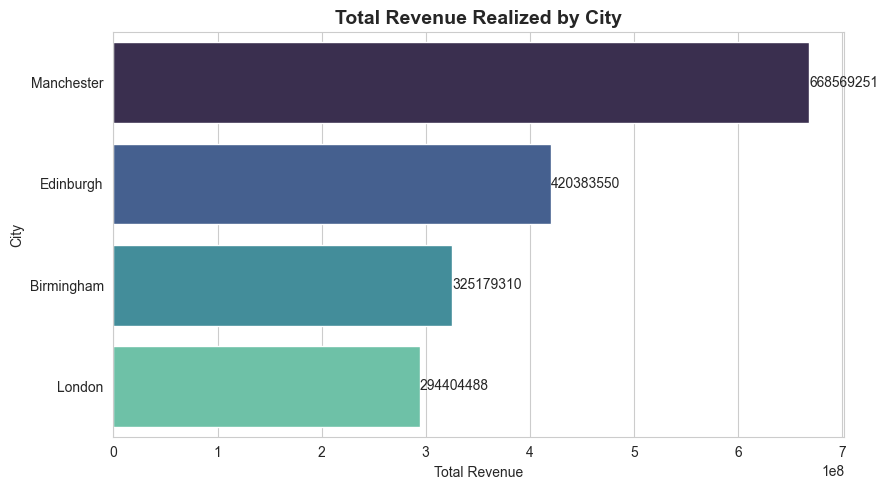

In [321]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate revenue by city
revenue_city = (
    df_bookings_all.groupby('city')['revenue_realized']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

plt.figure(figsize=(9,5))

ax = sns.barplot(
    data=revenue_city,
    y='city',
    x='revenue_realized',
    hue='city',
    palette='mako',
    legend=False
)

plt.title("Total Revenue Realized by City", fontsize=14, fontweight="bold")
plt.xlabel("Total Revenue")
plt.ylabel("City")

# Add labels
for container in ax.containers:
    ax.bar_label(container, fmt="%.0f")

plt.tight_layout()
plt.show()

## print month by month revenue

In [194]:
df_date['mmm yy'].unique()

array(['May 22', 'Jun 22', 'Jul 22'], dtype=object)

In [195]:
df_bookings_all.head(3)

,booking_id,property_id,booking_date,check_in_date,checkout_date,no_guests,room_category,booking_platform,ratings_given,booking_status,revenue_generated,revenue_realized,property_name,category,city
0,May012216558RT12,16558,30-04-22,1/5/2022,2/5/2022,2.0,RT1,others,NaN,Cancelled,9100,3640,Royal Thames Hotel,Luxury,London
1,May012216558RT15,16558,27-04-22,1/5/2022,2/5/2022,4.0,RT1,direct online,5.0,Checked Out,10920,10920,Royal Thames Hotel,Luxury,London
2,May012216558RT16,16558,1/5/2022,1/5/2022,3/5/2022,2.0,RT1,others,4.0,Checked Out,9100,9100,Royal Thames Hotel,Luxury,London


In [196]:
df_date.head(3)

,date,mmm yy,week no,day_type
0,01-May-22,May 22,W 19,weekend
1,02-May-22,May 22,W 19,weekeday
2,03-May-22,May 22,W 19,weekeday


In [197]:
df_bookings_all.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 134573 entries, 0 to 134572
Data columns (total 15 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   booking_id         134573 non-null  object 
 1   property_id        134573 non-null  int64  
 2   booking_date       134573 non-null  object 
 3   check_in_date      134573 non-null  object 
 4   checkout_date      134573 non-null  object 
 5   no_guests          134573 non-null  float64
 6   room_category      134573 non-null  object 
 7   booking_platform   134573 non-null  object 
 8   ratings_given      56676 non-null   float64
 9   booking_status     134573 non-null  object 
 10  revenue_generated  134573 non-null  int64  
 11  revenue_realized   134573 non-null  int64  
 12  property_name      134573 non-null  object 
 13  category           134573 non-null  object 
 14  city               134573 non-null  object 
dtypes: float64(2), int64(3), object(10)
memory usage: 1

In [198]:
df_date.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92 entries, 0 to 91
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   date      92 non-null     object
 1   mmm yy    92 non-null     object
 2   week no   92 non-null     object
 3   day_type  92 non-null     object
dtypes: object(4)
memory usage: 3.0+ KB


### Convert Date Columns to Datetime Format

In [324]:
# =====================================================
# Step 1: Convert date columns to datetime format
# =====================================================

# Convert date column in date dimension table
df_date["date"] = pd.to_datetime(df_date["date"])

# Convert check-in date in bookings dataset
df_bookings_all["check_in_date"] = pd.to_datetime(
    df_bookings_all["check_in_date"],
    format="mixed",
    dayfirst=True,
    errors="coerce"
)

# Preview datasets
df_date.head(3)


,date,mmm yy,week no,day_type
0,2022-05-01,May 22,W 19,weekend
1,2022-05-02,May 22,W 19,weekeday
2,2022-05-03,May 22,W 19,weekeday


In [325]:
df_bookings_all.head(3)

,booking_id,property_id,booking_date,check_in_date,checkout_date,no_guests,room_category,booking_platform,ratings_given,booking_status,revenue_generated,revenue_realized,property_name,category,city
0,May012216558RT12,16558,30-04-22,2022-05-01,2/5/2022,2.0,RT1,others,NaN,Cancelled,9100,3640,Royal Thames Hotel,Luxury,London
1,May012216558RT15,16558,27-04-22,2022-05-01,2/5/2022,4.0,RT1,direct online,5.0,Checked Out,10920,10920,Royal Thames Hotel,Luxury,London
2,May012216558RT16,16558,1/5/2022,2022-05-01,3/5/2022,2.0,RT1,others,4.0,Checked Out,9100,9100,Royal Thames Hotel,Luxury,London


In [327]:
df_date.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92 entries, 0 to 91
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   date      92 non-null     datetime64[ns]
 1   mmm yy    92 non-null     object        
 2   week no   92 non-null     object        
 3   day_type  92 non-null     object        
dtypes: datetime64[ns](1), object(3)
memory usage: 3.0+ KB


### Merge bookings dataset with date dataset

In [328]:
# =====================================================
# Step 2: Merge bookings dataset with date dataset
# =====================================================

df_bookings_final = pd.merge(
    df_bookings_all,
    df_date,
    left_on='check_in_date',
    right_on='date'
)

df_bookings_final.head(5)

,booking_id,property_id,booking_date,check_in_date,checkout_date,no_guests,room_category,booking_platform,ratings_given,booking_status,revenue_generated,revenue_realized,property_name,category,city,date,mmm yy,week no,day_type
0,May012216558RT12,16558,30-04-22,2022-05-01,2/5/2022,2.0,RT1,others,NaN,Cancelled,9100,3640,Royal Thames Hotel,Luxury,London,2022-05-01,May 22,W 19,weekend
1,May012216558RT15,16558,27-04-22,2022-05-01,2/5/2022,4.0,RT1,direct online,5.0,Checked Out,10920,10920,Royal Thames Hotel,Luxury,London,2022-05-01,May 22,W 19,weekend
2,May012216558RT16,16558,1/5/2022,2022-05-01,3/5/2022,2.0,RT1,others,4.0,Checked Out,9100,9100,Royal Thames Hotel,Luxury,London,2022-05-01,May 22,W 19,weekend
3,May012216558RT17,16558,28-04-22,2022-05-01,6/5/2022,2.0,RT1,others,NaN,Cancelled,9100,3640,Royal Thames Hotel,Luxury,London,2022-05-01,May 22,W 19,weekend
4,May012216558RT18,16558,26-04-22,2022-05-01,3/5/2022,2.0,RT1,logtrip,NaN,No Show,9100,9100,Royal Thames Hotel,Luxury,London,2022-05-01,May 22,W 19,weekend


### Calculate Month-Wise Revenue

In [330]:
# =====================================================
# Step 3: Calculate revenue per month
# =====================================================

monthly_revenue = (
    df_bookings_final
    .groupby("mmm yy")["revenue_realized"]
    .sum()
)

monthly_revenue

mmm yy
Jul 22    572843348
Jun 22    553925855
May 22    581767396
Name: revenue_realized, dtype: int64

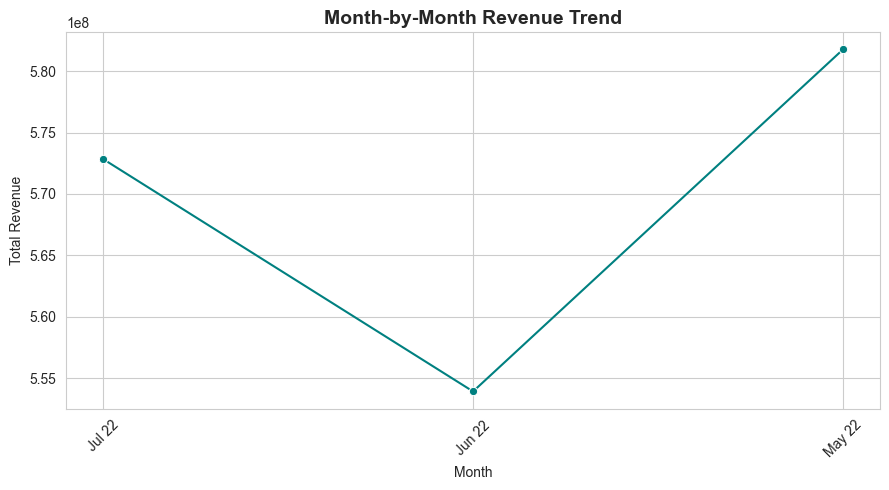

In [332]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(9,5))

sns.lineplot(
    x=monthly_revenue.index,
    y=monthly_revenue.values,
    marker="o",
    color="teal"
)

plt.title("Month-by-Month Revenue Trend", fontsize=14, fontweight="bold")
plt.xlabel("Month")
plt.ylabel("Total Revenue")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Business Insight

Monthly revenue trends help hotels identify high-demand seasons and low-demand periods. This information can guide pricing strategies, promotions, and staffing decisions.

# Print revenue realized per hotel?


In [333]:
# =====================================================
# Step 1: Calculate total revenue realized by each property
# =====================================================

revenue_property = (
    df_bookings_final
    .groupby("property_name")["revenue_realized"]
    .sum()
    .round(2)
    .sort_values(ascending=False)
)

print("Total Revenue by Property:")
print(revenue_property)

Total Revenue by Property:
property_name
Westminster Grand           320258588
Buckingham Palace Suites    304081863
Crown Plaza London          285798439
The Kensington Blu          260851922
Riverfront Bay Hotel        259996918
Royal Thames Hotel          211462134
Mayfair Seasons              66086735
Name: revenue_realized, dtype: int64


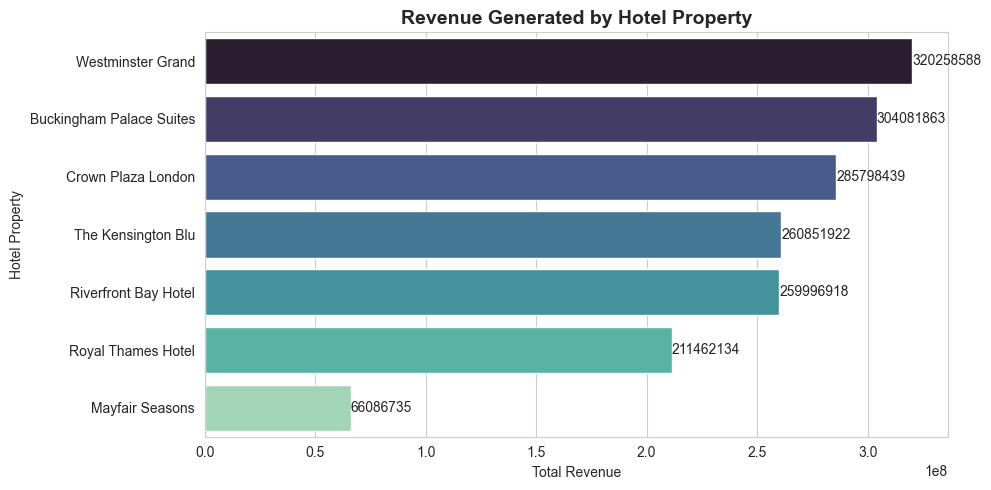

In [335]:
import seaborn as sns
import matplotlib.pyplot as plt

# Convert series to dataframe for plotting
revenue_property_df = revenue_property.reset_index()

plt.figure(figsize=(10,5))

ax = sns.barplot(
    data=revenue_property_df,
    y="property_name",
    x="revenue_realized",
    hue="property_name",
    palette="mako",
    legend=False
)

plt.title("Revenue Generated by Hotel Property", fontsize=14, fontweight="bold")
plt.xlabel("Total Revenue")
plt.ylabel("Hotel Property")

# Add labels
for container in ax.containers:
    ax.bar_label(container, fmt="%.0f")

plt.tight_layout()
plt.show()

# What is the average customer rating for each city?

This analysis helps understand customer satisfaction levels across different cities where the hotels operate.

In [336]:
# =====================================================
# Step 1: Calculate average customer rating by city
# =====================================================

avg_rating_city = (
    df_bookings_all
    .groupby("city")["ratings_given"]
    .mean()
    .round(2)
)

print("Average Customer Rating by City:")
print(avg_rating_city)

Average Customer Rating by City:
city
Birmingham    3.66
Edinburgh     3.41
London        3.78
Manchester    3.65
Name: ratings_given, dtype: float64


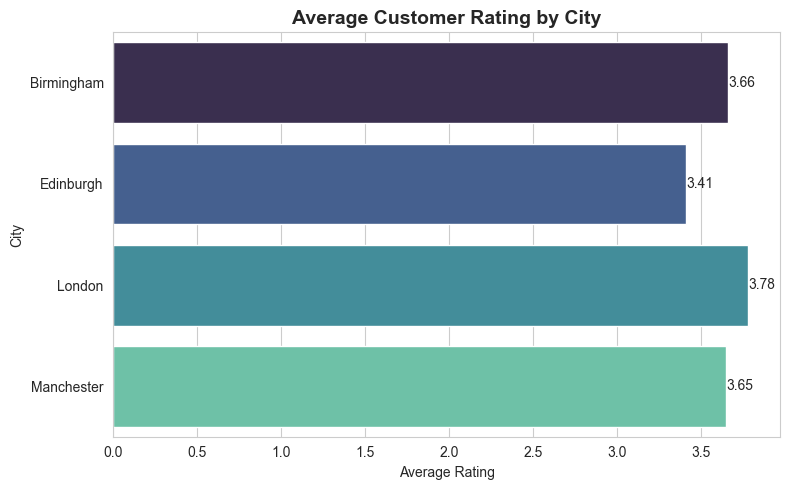

In [343]:
plt.figure(figsize=(8,5))

ax = sns.barplot(
    data=rating_city_df,
    y="city",
    x="ratings_given",
    hue="city",
    palette="mako",
    legend=False
)

plt.title("Average Customer Rating by City", fontsize=14, fontweight="bold")
plt.xlabel("Average Rating")
plt.ylabel("City")

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f")

plt.tight_layout()
plt.show()

# Business Insight

Customer ratings reflect guest satisfaction and service quality.
Cities with higher ratings indicate better guest experiences, while lower ratings may highlight areas where service improvements are needed.

# **Exercise-3 Print a Donot chart of revenue realized per booking platform**
Objective

This visualization shows how much revenue each booking platform contributes, helping identify the most important booking channels.

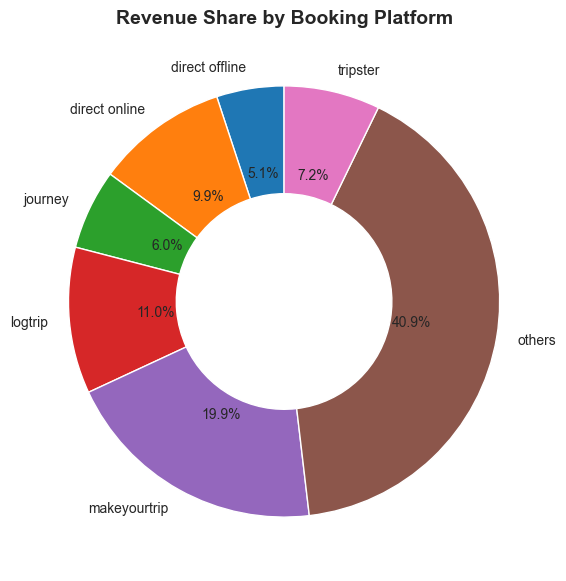

In [341]:
plt.figure(figsize=(7,7))

plt.pie(
    platform_revenue,
    labels=platform_revenue.index,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"width":0.5}
)

plt.title("Revenue Share by Booking Platform", fontsize=14, fontweight="bold")

plt.show()

## FINAL SECTION: KEY INSIGHTS AND CONCLUSIONS
#### 1. Room Category Performance
 Premium and Presidential rooms generated higher revenue,
 while Standard rooms maintained steady occupancy because
 they are more affordable for most customers.

#### 2. City-wise Hotel Performance
 Some cities showed higher occupancy and revenue levels,
 indicating stronger tourism demand and better hotel
 performance in those locations.

#### 3. Weekday vs Weekend Trends
 Occupancy rates were generally higher during weekends,
 suggesting leisure travel demand plays a key role in
 hotel bookings.

#### 4. Monthly Revenue Trend
 Revenue varied across months, indicating seasonal
 demand patterns within the hospitality industry.

#### 5. Booking Platform Contribution
 Certain booking platforms contributed a larger share
 of total revenue, highlighting the importance of
 online booking channels.

#### 6. Customer Rating Insights
 Average customer ratings differed across cities,
 which may reflect differences in service quality,
 customer expectations, and property performance.

#### FINAL NOTE
 This project demonstrates how hotel booking data can
 be analyzed using Python to extract meaningful insights
 related to occupancy trends, revenue performance,
 and customer satisfaction.

#Author

## Faisal Shahzad
Data Analytics Enthusiast

🔗 LinkedIn: https://www.linkedin.com/in/faisal-analyst/

# Thank You